# Car Rental Transformed Analytics
This notebook performs 20 practical transformation scenarios on `car_rental_cleaned_dataset.csv`.

Notes:
- Some use-cases (scheduled SLA, add-ons, subscription) are not directly available in source columns, so lightweight, clearly-labeled proxy assumptions are used.
- The focus is simple, reproducible transformation logic using pandas/numpy with quick visuals via matplotlib/seaborn.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

df = pd.read_csv("../Datasets/car_rental_cleaned_dataset.csv")

required_defaults = {
    "Reservation_ID": "",
    "Customer_ID": "",
    "Vehicle_ID": "",
    "Vehicle_Class": "Unknown",
    "Booking_Status": "Unknown",
    "Booking_TS": pd.NaT,
    "Pickup_TS": pd.NaT,
    "Return_TS": pd.NaT,
    "Odo_Start": np.nan,
    "Odo_End": np.nan,
    "Fuel_Level": np.nan,
    "Rate": np.nan,
    "Promo_Code": "",
    "City": "Unknown",
    "GPS_Lat": np.nan,
    "GPS_Lon": np.nan,
    "Speed": np.nan,
    "Damage_Flag": "None",
    "Notes": "",
    "Vehicle_ID_Invalid": False,
    "Duration_Hours": np.nan,
    "expected_hours": np.nan,
    "Distance_Driven": np.nan,
    "Refuel_Event": "",
    "Driver_Behavior": "Unknown",
    "Total_Amount": np.nan,
}
for col, default in required_defaults.items():
    if col not in df.columns:
        df[col] = default

for col in ["Booking_TS", "Pickup_TS", "Return_TS", "Prev_Return", "Promo_Expiry"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

for col in ["Duration_Hours", "expected_hours", "Distance_Driven", "Odo_Start", "Odo_End", "Rate", "Total_Amount", "Fuel_Level", "Speed", "GPS_Lat", "GPS_Lon"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

bool_values = df["Vehicle_ID_Invalid"].astype(str).str.lower().str.strip()
df["vehicle_id_invalid_flag"] = bool_values.isin(["true", "1", "yes"])

df["is_completed"] = df["Booking_Status"].eq("Completed")
df["rental_hours"] = df["Duration_Hours"]
mask_missing_hours = df["rental_hours"].isna() & df["Pickup_TS"].notna() & df["Return_TS"].notna()
df.loc[mask_missing_hours, "rental_hours"] = (
    (df.loc[mask_missing_hours, "Return_TS"] - df.loc[mask_missing_hours, "Pickup_TS"]).dt.total_seconds() / 3600
)
df["rental_hours"] = df["rental_hours"].clip(lower=0)

df["distance_km"] = df["Distance_Driven"].clip(lower=0)
df["lead_time_hours"] = ((df["Pickup_TS"] - df["Booking_TS"]).dt.total_seconds() / 3600).clip(lower=0)
df["booking_month"] = df["Booking_TS"].dt.to_period("M").astype(str)
df["pickup_date"] = df["Pickup_TS"].dt.date

a_start = df["Pickup_TS"].min()
a_end = df["Return_TS"].max()
analysis_hours = max((a_end - a_start).total_seconds() / 3600, 1) if pd.notna(a_start) and pd.notna(a_end) else 1

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Analysis window hours: {analysis_hours:,.2f}")
print(df[["Reservation_ID", "City", "Vehicle_Class", "Booking_Status", "rental_hours", "expected_hours", "distance_km", "Rate", "Total_Amount"]].head())

Rows: 4,527 | Columns: 39
Analysis window hours: 8,159.15
  Reservation_ID     City Vehicle_Class Booking_Status  rental_hours  \
0      RES-00003    Delhi        Suzuki      Completed          71.0   
1      RES-03655   Mumbai        Suzuki      Completed          28.0   
2      RES-01774   Mumbai        Suzuki      Cancelled           3.0   
3      RES-03809  Chennai        Suzuki      Cancelled          38.0   
4      RES-01293   Mumbai        Suzuki      Cancelled        2163.0   

   expected_hours  distance_km    Rate  Total_Amount  
0            71.0        382.0  2000.0        2360.0  
1            28.0        211.0  2300.0        2714.0  
2             3.0          0.0  1840.0           0.0  
3            38.0          0.0  2000.0           0.0  
4          2163.0          0.0  1500.0           0.0  


## 1) Utilization = rental hours / fleet hours by city and vehicle class


         City Vehicle_Class  available_cars    fleet_hours  rental_hours  \
20      Delhi           SUV              13   76309.394412      57835.44   
7   Bengaluru        Toyota              10   56872.983333      42669.97   
13    Chennai         Sedan              15   83321.066667      54094.13   
31     Mumbai        Toyota              17   98207.233333      59256.75   
14    Chennai        Suzuki               9   56079.766667      32709.91   
28     Mumbai           SUV              18  104014.066667      56395.49   
9     Chennai            EV               9   56481.716667      27611.10   
3   Bengaluru        Luxury              17   95908.350000      42585.52   
10    Chennai     Hatchback              16   95115.066667      40584.26   
15    Chennai        Toyota              13   79469.716667      33437.33   
24     Mumbai         Creta              18  108194.766667      45352.39   
21      Delhi         Sedan              29  182665.416667      73512.57   

    utiliza

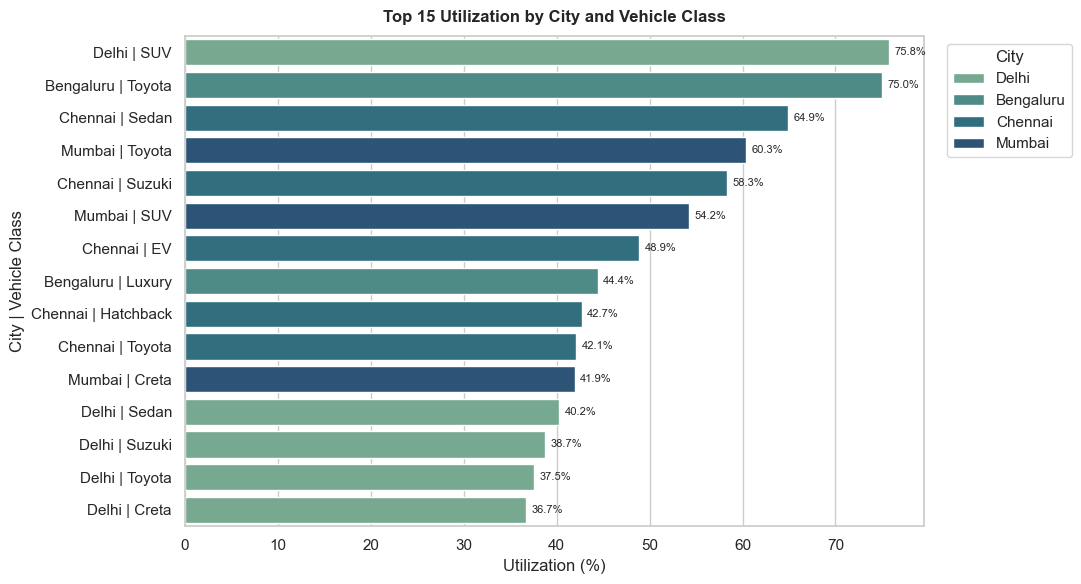

In [2]:
vehicle_activity = df.groupby("Vehicle_ID").agg(
    first_use=("Pickup_TS", "min"),
    last_use=("Return_TS", "max"),
    City=("City", "first"),
    Vehicle_Class=("Vehicle_Class", "first")
).reset_index()

vehicle_activity["active_hours"] = (
    vehicle_activity["last_use"] - vehicle_activity["first_use"]
).dt.total_seconds() / 3600

fleet = vehicle_activity.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    available_cars=("Vehicle_ID", "nunique"),
    fleet_hours=("active_hours", "sum")
)

rental = df.loc[df["is_completed"]].groupby(
    ["City", "Vehicle_Class"], dropna=False
)["rental_hours"].sum().rename("rental_hours")

util = pd.concat([fleet, rental], axis=1).fillna(0).reset_index()

util["utilization"] = np.where(
    util["fleet_hours"] > 0,
    util["rental_hours"] / util["fleet_hours"],
    0
)

util = util.sort_values("utilization", ascending=False)

print(util.head(12))

top_util = util.head(15).copy()
top_util["utilization_pct"] = (top_util["utilization"] * 100).round(2)
top_util["segment"] = top_util["City"].astype(str) + " | " + top_util["Vehicle_Class"].astype(str)
top_util = top_util.sort_values("utilization_pct", ascending=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=top_util,
    x="utilization_pct",
    y="segment",
    hue="City",
    palette="crest",
    dodge=False,
)
ax.set_title("Top 15 Utilization by City and Vehicle Class", pad=10, weight="bold")
ax.set_xlabel("Utilization (%)")
ax.set_ylabel("City | Vehicle Class")

for i, v in enumerate(top_util["utilization_pct"]):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=8)

ax.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

## 2) Revenue per available car (RevPAC) and yield metrics


In [3]:
completed = df[df["is_completed"]].copy()

metrics = completed.groupby(["City","Vehicle_Class"], dropna=False).agg(
    total_revenue=("Total_Amount","sum"),
    rental_hours=("rental_hours","sum")
).reset_index()

rev_metrics = util[["City","Vehicle_Class","available_cars"]].merge(
    metrics,
    on=["City","Vehicle_Class"],
    how="left"
).fillna(0)

rev_metrics["RevPAC"] = rev_metrics["total_revenue"] / rev_metrics["available_cars"]

rev_metrics["yield_per_hour"] = rev_metrics["total_revenue"] / rev_metrics["rental_hours"]

pd.options.display.float_format = "{:,.2f}".format

result = rev_metrics[
    ["City","Vehicle_Class","available_cars","total_revenue","RevPAC","yield_per_hour"]
].sort_values("RevPAC", ascending=False)

print(result.head(12))

         City Vehicle_Class  available_cars  total_revenue    RevPAC  \
0       Delhi           SUV              13     145,779.68 11,213.82   
4     Chennai        Suzuki               9      71,203.06  7,911.45   
1   Bengaluru        Toyota              10      78,188.66  7,818.87   
6     Chennai            EV               9      64,429.24  7,158.80   
12      Delhi        Suzuki              19     125,812.84  6,621.73   
9     Chennai        Toyota              13      82,107.50  6,315.96   
10     Mumbai         Creta              18     113,094.92  6,283.05   
2     Chennai         Sedan              15      94,165.24  6,277.68   
19      Delhi     Hatchback              27     160,812.88  5,956.03   
7   Bengaluru        Luxury              17      97,871.68  5,757.16   
30     Mumbai            EV              15      83,119.82  5,541.32   
3      Mumbai        Toyota              17      92,304.56  5,429.68   

    yield_per_hour  
0             2.52  
4             2.18  


## 3) Distance driven and cost per km


         City Vehicle_Class  total_distance_km  cost_per_km  trips
0   Bengaluru         Creta           8,746.00        23.91     44
1   Bengaluru            EV           7,544.00        21.07     36
2   Bengaluru     Hatchback           9,160.00        19.09     42
3   Bengaluru        Luxury          11,324.00        16.71     44
4   Bengaluru           SUV           7,488.00        21.02     38
5   Bengaluru         Sedan          11,066.00        15.28     38
6   Bengaluru        Suzuki           8,887.00        20.43     45
7   Bengaluru        Toyota           7,932.00        21.82     34
8     Chennai         Creta           6,678.00        23.65     31
9     Chennai            EV           6,209.00        21.17     30
10    Chennai     Hatchback           6,616.00        25.14     36
11    Chennai        Luxury           9,446.00        19.73     35
12    Chennai           SUV           5,536.00        15.71     24
13    Chennai         Sedan           8,567.00        19.92   

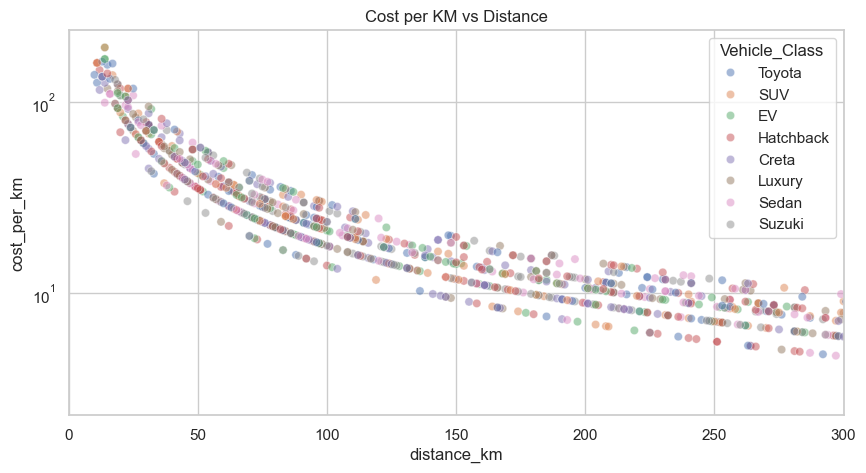

In [4]:
min_distance_km = 10

# Filter valid trips
trip = df[
    (df["is_completed"]) &
    (df["distance_km"] >= min_distance_km) &
    (df["Total_Amount"] > 0)
].copy()

# Cost per km
trip["cost_per_km"] = trip["Total_Amount"] / trip["distance_km"]

# Remove extreme outliers (top 1%)
trip = trip[
    (trip["distance_km"] <= trip["distance_km"].quantile(0.99)) &
    (trip["cost_per_km"] <= trip["cost_per_km"].quantile(0.99))
]

# Aggregated metrics
distance_cost = trip.groupby(["City", "Vehicle_Class"]).agg(
    total_distance_km=("distance_km", "sum"),
    cost_per_km=("cost_per_km", "mean"),
    trips=("Reservation_ID", "count")
).reset_index()

print(distance_cost.head(20))

# Plot
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=trip.sample(min(len(trip), 2000), random_state=42),
    x="distance_km",
    y="cost_per_km",
    hue="Vehicle_Class",
    alpha=0.5
)

plt.yscale("log")
plt.title("Cost per KM vs Distance")
plt.xlabel("distance_km")
plt.ylabel("cost_per_km")
plt.xlim(0, 300)
plt.show()

## 4) Idle time and repositioning analytics


In [5]:
# sort trips by vehicle and pickup time
seq = df.sort_values(["Vehicle_ID", "Pickup_TS"])

# get previous trip return time and city for the same vehicle
seq["prev_return_ts"] = seq.groupby("Vehicle_ID")["Return_TS"].shift()
seq["prev_city"] = seq.groupby("Vehicle_ID")["City"].shift()

# calculate idle time between trips
seq["idle_hours"] = (seq["Pickup_TS"] - seq["prev_return_ts"]).dt.total_seconds() / 3600
seq["idle_hours"] = seq["idle_hours"].clip(lower=0)

# check if vehicle moved to a different city
seq["repositioned"] = (seq["City"] != seq["prev_city"]) & seq["prev_city"].notna()

# summarize idle behaviour per vehicle
idle_summary = seq.groupby("Vehicle_ID").agg(
    avg_idle_hours=("idle_hours", "mean"),
    reposition_events=("repositioned", "sum")
).reset_index()

# show vehicles with highest idle time
print(idle_summary.head(10))
print(idle_summary.shape)


  Vehicle_ID  avg_idle_hours  reposition_events
0    CAR-001          816.33                  4
1    CAR-002          770.36                  4
2    CAR-003          434.77                  6
3    CAR-005          446.77                  8
4    CAR-006          714.11                  2
5    CAR-007          367.31                  1
6    CAR-008          774.27                  5
7    CAR-009          830.59                  4
8    CAR-010          574.33                  4
9    CAR-011        1,284.07                  3
(600, 3)


## 5) Dynamic pricing features (demand, lead time, seasonality)


     Reservation_ID     City Vehicle_Class  lead_time_hours  daily_demand
963       RES-02184   Mumbai        Luxury             0.75            10
219       RES-01448  Chennai     Hatchback             0.77             4
4266      RES-01263  Chennai         Sedan             1.03             6
3542      RES-01671  Chennai        Luxury            17.78             5
3732      RES-04260  Chennai     Hatchback            18.55             6
2662      RES-02274   Mumbai         Sedan            18.87            10
3042      RES-02899  Chennai        Luxury            19.00             9
        City Vehicle_Class  month  daily_demand
0  Bengaluru         Creta      1          8.60
1  Bengaluru         Creta      2          6.69
2  Bengaluru         Creta      3          6.37
3  Bengaluru         Creta      4          7.33
4  Bengaluru         Creta      5          7.96


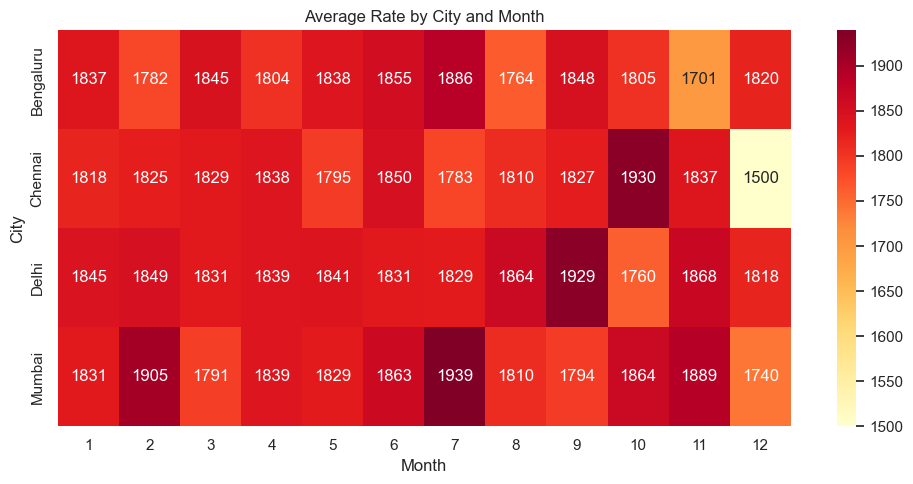

In [6]:
# TRANFORM 5

pricing = df.copy()

pricing["month"] = pricing["Pickup_TS"].dt.month

pricing["daily_demand"] = pricing.groupby(["City", "pickup_date"])["Reservation_ID"].transform("count")
pricing = pricing.sort_values("lead_time_hours", ascending=True)

print(pricing[["Reservation_ID","City","Vehicle_Class","lead_time_hours","daily_demand"]].head(7))

# NEW: show average daily demand by month
monthly_demand = pricing.groupby(
    ["City","Vehicle_Class","month"]
)["daily_demand"].mean().reset_index()

print(monthly_demand.head(5))

plt.figure(figsize=(10,5))

heat_data = pricing.pivot_table(
    values="Rate",
    index="City",
    columns="month",
    aggfunc="mean"
)

sns.heatmap(
    heat_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Average Rate by City and Month")
plt.xlabel("Month")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## 6) Fuel efficiency estimates by model


  Vehicle_Class  trips  avg_fuel_efficiency
3        Luxury    163             1,166.27
6        Suzuki    181             1,162.61
0         Creta    210             1,054.67
7        Toyota    191               972.36
5         Sedan    191               905.45
2     Hatchback    212               811.67
4           SUV    171               791.95


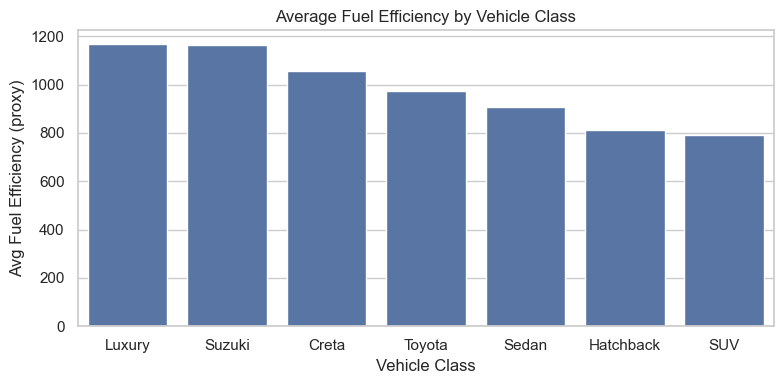

In [7]:
fuel = df[(df["is_completed"]) & (df["distance_km"] > 0)].copy()

fuel["fuel_used_proxy"] = (
    1 - fuel["Fuel_Level"].fillna(fuel["Fuel_Level"].median())
).clip(0.05, 1)

fuel["fuel_efficiency_proxy"] = fuel["distance_km"] / fuel["fuel_used_proxy"]

fuel_eff = fuel.groupby("Vehicle_Class", dropna=False).agg(
    trips=("Reservation_ID", "count"),
    avg_fuel_efficiency=("fuel_efficiency_proxy", "mean")
).round(2).reset_index().sort_values("avg_fuel_efficiency", ascending=False)

fuel_eff = fuel_eff[fuel_eff["Vehicle_Class"] != "EV"]

print(fuel_eff)

fuel_eff_plot = fuel_eff[fuel_eff["Vehicle_Class"] != "EV"]
plt.figure(figsize=(8,4))

sns.barplot(
    data=fuel_eff_plot,
    x="Vehicle_Class",
    y="avg_fuel_efficiency"
)

plt.title("Average Fuel Efficiency by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Avg Fuel Efficiency (proxy)")

plt.tight_layout()
plt.show()


## 7) Damage incidence rate per 100 rentals


         City Vehicle_Class  rentals  damage_events  damage_per_100_rentals
7   Bengaluru        Toyota      117             91                   77.78
13    Chennai         Sedan      111             82                   73.87
27     Mumbai        Luxury      108             79                   73.15
1   Bengaluru            EV      128             93                   72.66
29     Mumbai         Sedan      117             84                   71.79
31     Mumbai        Toyota      145            103                   71.03
24     Mumbai         Creta      187            132                   70.59
12    Chennai           SUV       80             56                   70.00
30     Mumbai        Suzuki      129             90                   69.77
14    Chennai        Suzuki       94             65                   69.15


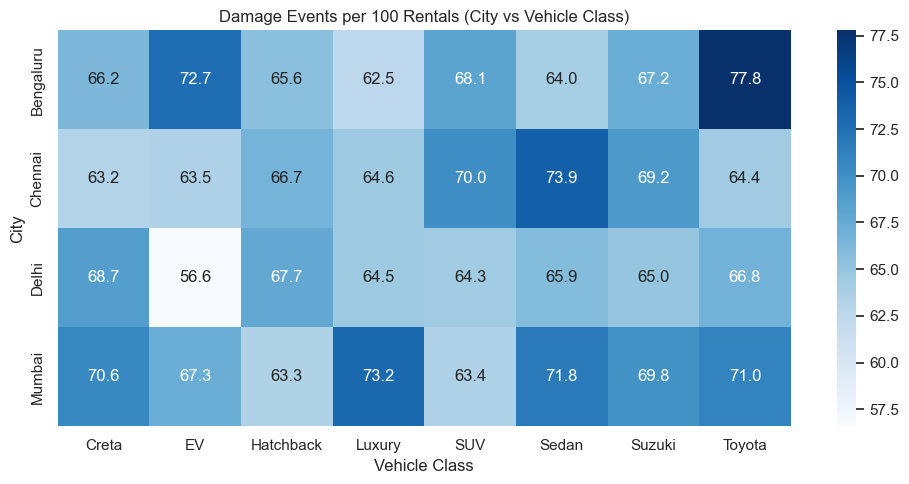

In [8]:
damage = df.copy()

damage["damage_event"] = damage["Damage_Flag"].fillna("None") != "None"

damage_rate = damage.groupby(["City", "Vehicle_Class"]).agg(
    rentals=("Reservation_ID", "count"),
    damage_events=("damage_event", "sum")
).reset_index()

damage_rate["damage_per_100_rentals"] = (
    100 * damage_rate["damage_events"] / damage_rate["rentals"]
).round(2)

print(damage_rate.sort_values("damage_per_100_rentals", ascending=False).head(10))

pivot_damage = damage_rate.pivot(
    index="City",
    columns="Vehicle_Class",
    values="damage_per_100_rentals"
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot_damage,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Damage Events per 100 Rentals (City vs Vehicle Class)")
plt.xlabel("Vehicle Class")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## 8) Customer cohort retention and NPS rollups


In [9]:
cust = df[df["is_completed"]].copy()
cust["booking_month_period"] = cust["Booking_TS"].dt.to_period("M")
cohort_month = cust.groupby("Customer_ID")["booking_month_period"].min().rename("cohort_month")
cust = cust.join(cohort_month, on="Customer_ID")

valid = cust.dropna(subset=["booking_month_period", "cohort_month"]).copy()
valid["cohort_index"] = valid["booking_month_period"].astype(int) - valid["cohort_month"].astype(int)

ret_counts = valid.groupby(["cohort_month", "cohort_index"])["Customer_ID"].nunique().unstack(fill_value=0)
if not ret_counts.empty:
    base = ret_counts.iloc[:, 0]
    retention = ret_counts.div(base, axis=0).round(3)
    print("Retention matrix (first rows):")
    print(retention.head())
else:
    print("Retention matrix unavailable (insufficient date data).")

valid["nps_bucket"] = np.select(
    [
        (valid["Driver_Behavior"].eq("Normal Driving") | valid["Damage_Flag"].eq("None")),
        (valid["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | valid["Damage_Flag"].eq("Major")),
    ],
    ["Promoter", "Detractor"],
    default="Passive",
)

nps_rollup = valid.groupby("cohort_month")["nps_bucket"].value_counts(normalize=True).unstack(fill_value=0)
nps_rollup["NPS"] = (nps_rollup.get("Promoter", 0) - nps_rollup.get("Detractor", 0)) * 100
print("\nNPS by cohort month:")
print(nps_rollup[[c for c in ["Promoter", "Passive", "Detractor", "NPS"] if c in nps_rollup.columns]].head(12))


Retention matrix (first rows):
cohort_index   0    1    2    3    4    5    6    7    8    9    10
cohort_month                                                       
2024-12      1.00 0.07 0.09 0.11 0.07 0.11 0.04 0.00 0.00 0.00 0.02
2025-01      1.00 0.09 0.12 0.09 0.10 0.10 0.01 0.00 0.00 0.00 0.00
2025-02      1.00 0.15 0.13 0.11 0.08 0.00 0.00 0.01 0.01 0.01 0.00
2025-03      1.00 0.08 0.07 0.11 0.01 0.00 0.00 0.00 0.00 0.00 0.00
2025-04      1.00 0.09 0.07 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00

NPS by cohort month:
nps_bucket    Promoter  Passive  Detractor     NPS
cohort_month                                      
2024-12           0.30     0.15       0.55  -25.35
2025-01           0.26     0.15       0.60  -34.14
2025-02           0.33     0.10       0.57  -24.14
2025-03           0.31     0.16       0.53  -21.34
2025-04           0.24     0.17       0.60  -36.09
2025-05           0.24     0.15       0.60  -35.88
2025-06           0.30     0.14       0.57  -27.27
2025-07     

## 9) Fraud risk score (short returns, odometer anomalies)


        City  high_risk_pct  total_reservations
3     Mumbai           0.38                1061
0  Bengaluru           0.19                1041
1    Chennai           0.13                 798
2      Delhi           0.12                1627


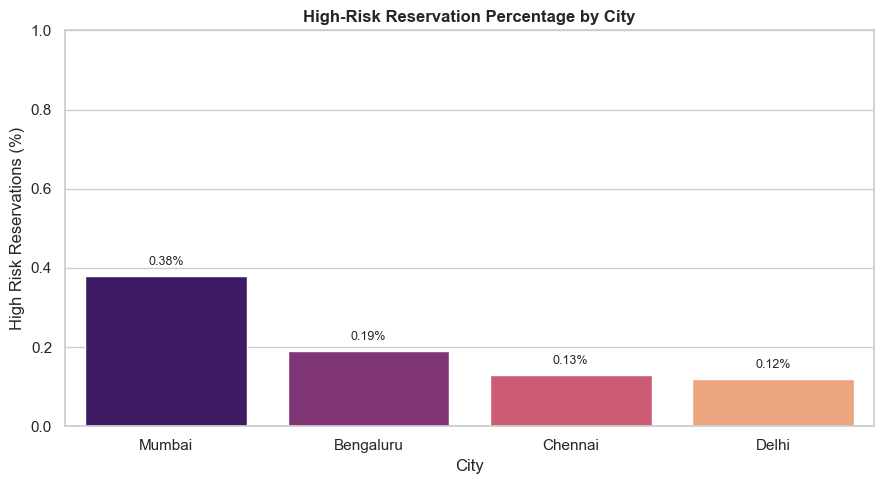

In [10]:
# TRANSFORM 9 --> High-risk percentage by city

fraud = df.copy()

# Build fraud risk score
fraud["short_return_flag"] = fraud["is_completed"] & (fraud["rental_hours"] < 2)
fraud["odo_diff"] = fraud["Odo_End"] - fraud["Odo_Start"]
fraud["odo_anomaly_flag"] = (fraud["odo_diff"] < 0) | ((fraud["odo_diff"] - fraud["distance_km"]).abs() > 50)
fraud["speed_risk_flag"] = fraud["Speed"] > 120

fraud["fraud_risk_score"] = (
    30 * fraud["short_return_flag"].astype(int)
    + 50 * fraud["odo_anomaly_flag"].fillna(False).astype(int)
    + 20 * fraud["speed_risk_flag"].fillna(False).astype(int)
    + 20 * fraud["vehicle_id_invalid_flag"].astype(int)
).clip(0, 100)

# High risk = score >= 50
city_high_risk = (
    fraud.assign(high_risk=fraud["fraud_risk_score"] >= 50)
    .groupby("City", dropna=False)
    .agg(high_risk_pct=("high_risk", "mean"), total_reservations=("Reservation_ID", "count"))
    .reset_index()
    .sort_values("high_risk_pct", ascending=False)
)

city_high_risk["high_risk_pct"] = (city_high_risk["high_risk_pct"] * 100).round(2)
print(city_high_risk[["City", "high_risk_pct", "total_reservations"]])

# Simple graph: high-risk percentage by city
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=city_high_risk,
    x="City",
    y="high_risk_pct",
    hue="City",
    palette="magma",
    legend=False,
 )
ax.set_title("High-Risk Reservation Percentage by City", weight="bold")
ax.set_xlabel("City")
ax.set_ylabel("High Risk Reservations (%)")

max_pct = city_high_risk["high_risk_pct"].max()
ax.set_ylim(0, max(max_pct * 1.35, 1))

offset = max(max_pct * 0.03, 0.02)
for i, v in enumerate(city_high_risk["high_risk_pct"]):
    ax.text(i, v + offset, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 10) Maintenance due forecast (km/time based)


In [11]:
# Filter to Completed trips only — odometer readings are only meaningful here
df_completed = df[df["Booking_Status"] == "Completed"]

latest = (
    df_completed
    .sort_values("Return_TS")
    .groupby("Vehicle_ID", as_index=False)
    .tail(1)
    .copy()
)

latest["current_odometer"] = latest["Odo_End"].fillna(latest["Odo_Start"])
latest["km_to_next_service"] = 10000 - (latest["current_odometer"] % 10000)
latest["days_since_last_return"] = (
    pd.Timestamp.today().normalize() - latest["Return_TS"]
).dt.days

latest["maintenance_due"] = (
    (latest["km_to_next_service"] <= 500) | (latest["days_since_last_return"] >= 180)
)

# Fix: clip days score at 1, not 2, so final score stays in [0, 1]
latest["maintenance_priority"] = (
    ((500 - latest["km_to_next_service"]).clip(lower=0) / 500) * 0.6
    + (latest["days_since_last_return"].clip(lower=0) / 180).clip(upper=1) * 0.4
)

print(
    latest[[
        "Vehicle_ID", "Vehicle_Class", "current_odometer",
        "km_to_next_service", "days_since_last_return",
        "maintenance_due", "maintenance_priority"
    ]]
    .sort_values(["maintenance_due", "maintenance_priority"], ascending=[False, False])
    .head(20)
)

     Vehicle_ID Vehicle_Class  current_odometer  km_to_next_service  \
1257    CAR-173        Suzuki         59,935.00               65.00   
1361    CAR-186        Toyota         69,928.00               72.00   
4378    CAR-582        Suzuki         59,910.00               90.00   
4267    CAR-567         Sedan         49,894.00              106.00   
1106    CAR-153        Toyota         49,870.00              130.00   
1519    CAR-207     Hatchback         59,952.00               48.00   
4128    CAR-552         Sedan         59,864.00              136.00   
3446    CAR-463        Suzuki         69,911.00               89.00   
403     CAR-051         Creta         29,956.00               44.00   
4027    CAR-539         Creta         29,809.00              191.00   
3640    CAR-489        Luxury         19,801.00              199.00   
4063    CAR-544         Creta         29,769.00              231.00   
1368    CAR-187            EV         69,767.00              233.00   
2506  

## 11) Overstay detection and penalty calculation


Simple method used below: `overstay_hours = max((expected_hours - Duration_Hours), 0)`.

Rows evaluated: 1,487
Rows with overstay_hours > 0: 136


Reservation_ID,Vehicle_Class,overstay_hours,overstay_penalty
RES-01058,Creta,8.90,226.21
RES-01562,Sedan,8.79,217.29
RES-00796,Hatchback,8.73,238.76
RES-00007,Creta,8.69,237.05
RES-03490,EV,8.68,236.70
RES-01003,Suzuki,8.68,177.51
RES-01506,Suzuki,8.67,212.44
RES-01784,Creta,8.64,215.56
RES-01089,Toyota,8.62,215.59
RES-00522,Creta,8.58,213.35


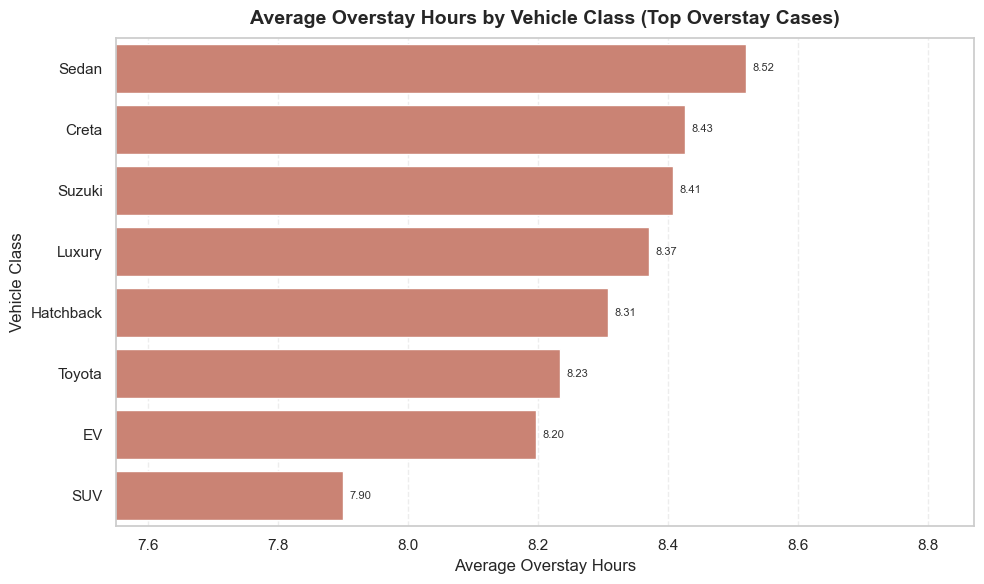

In [12]:
overstay = df[df["is_completed"]].copy()
overstay = overstay[
    (overstay["Rate"] > 0)
    & overstay["Duration_Hours"].notna()
    & overstay["expected_hours"].notna()
] .copy()

# Requested simple logic: expected_hours - Duration_Hours
overstay["overstay_hours"] = (
    overstay["expected_hours"] - overstay["Duration_Hours"]
).clip(lower=0)

# Penalty calculation
overstay["hourly_rate"] = overstay["Rate"] / 24
h = overstay["overstay_hours"].clip(upper=72)
overstay["penalty_first_6h"] = np.minimum(h, 6) * 0.25 * overstay["hourly_rate"]
overstay["penalty_next_18h"] = np.minimum(np.clip(h - 6, 0, None), 18) * 0.50 * overstay["hourly_rate"]
overstay["penalty_after_24h"] = np.clip(h - 24, 0, None) * 1.00 * overstay["hourly_rate"]
overstay["overstay_penalty"] = (
    overstay["penalty_first_6h"]
    + overstay["penalty_next_18h"]
    + overstay["penalty_after_24h"]
)

# Final hard cap
overstay["overstay_penalty"] = np.minimum(overstay["overstay_penalty"], overstay["Rate"] * 1.25)

overstay_positive = overstay[overstay["overstay_hours"] > 0].copy()

print(f"Rows evaluated: {len(overstay):,}")
print(f"Rows with overstay_hours > 0: {len(overstay_positive):,}")

imp_cols = [
    "Reservation_ID",
    "Vehicle_Class",
    "overstay_hours",
    "overstay_penalty",
]
top_overstay = overstay_positive[imp_cols].sort_values(
    ["overstay_hours", "overstay_penalty"], ascending=False
).head(30).round(2)

from IPython.display import HTML, display
display(HTML("<h4>Top Overstay Results (expected_hours - Duration_Hours)</h4>" + top_overstay.to_html(index=False)))

# Vehicle class only graph: average overstay hours
class_overstay = (
    top_overstay.groupby("Vehicle_Class", dropna=False)
    .agg(
        avg_overstay_hours=("overstay_hours", "mean"),
        cases=("Reservation_ID", "count"),
    )
    .reset_index()
    .sort_values("avg_overstay_hours", ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=class_overstay,
    y="Vehicle_Class",
    x="avg_overstay_hours",
    color="#d87a66",
)

ax.set_title("Average Overstay Hours by Vehicle Class (Top Overstay Cases)", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Average Overstay Hours")
ax.set_ylabel("Vehicle Class")
ax.grid(axis="x", linestyle="--", alpha=0.35)

xmin = max(class_overstay["avg_overstay_hours"].min() - 0.35, 0)
xmax = class_overstay["avg_overstay_hours"].max() + 0.35
ax.set_xlim(xmin, xmax)

for i, row in class_overstay.reset_index(drop=True).iterrows():
    ax.text(
        row["avg_overstay_hours"] + 0.01,
        i,
        f"{row['avg_overstay_hours']:.2f}",
        va="center",
        fontsize=8,
        color="#333333",
    )

plt.tight_layout()
plt.show()

## 12) Pickup/return punctuality stats


In [13]:
completed = df[df["is_completed"]].copy()

# ----------------------------------------
# Pickup punctuality proxy (consistency)
# ----------------------------------------
pickup_base = completed.dropna(subset=["Booking_TS", "Pickup_TS"]).copy()
pickup_base["lead_time_hours"] = (pickup_base["Pickup_TS"] - pickup_base["Booking_TS"]).dt.total_seconds() / 3600

# Use only plausible lead times for proxy modeling.
pickup_base = pickup_base[pickup_base["lead_time_hours"].between(0, 24 * 14)].copy()

lead_bins = [0, 6, 24, 72, 168, 24 * 14]
lead_labels = ["0-6h", "6-24h", "1-3d", "3-7d", "7-14d"]
pickup_base["lead_time_bucket"] = pd.cut(
    pickup_base["lead_time_hours"],
    bins=lead_bins,
    labels=lead_labels,
    include_lowest=True,
)

bucket_baseline = (
    pickup_base.groupby(["City", "lead_time_bucket"], dropna=False, observed=False)["lead_time_hours"]
    .median()
    .rename("bucket_median_lead_h")
    .reset_index()
)

bucket_spread = (
    pickup_base.groupby(["City", "lead_time_bucket"], dropna=False, observed=False)["lead_time_hours"]
    .quantile([0.25, 0.75])
    .unstack()
    .reset_index()
    .rename(columns={0.25: "bucket_q1_h", 0.75: "bucket_q3_h"})
)

city_baseline = (
    pickup_base.groupby("City", dropna=False)["lead_time_hours"]
    .median()
    .rename("city_median_lead_h")
    .reset_index()
)
global_median_lead_h = pickup_base["lead_time_hours"].median()

pickup_eval = (
    pickup_base
    .merge(bucket_baseline, on=["City", "lead_time_bucket"], how="left")
    .merge(bucket_spread, on=["City", "lead_time_bucket"], how="left")
    .merge(city_baseline, on="City", how="left")
)

pickup_eval["expected_lead_h"] = (
    pickup_eval["bucket_median_lead_h"]
    .fillna(pickup_eval["city_median_lead_h"])
).fillna(global_median_lead_h)

pickup_eval["scheduled_pickup_proxy"] = pickup_eval["Booking_TS"] + pd.to_timedelta(
    pickup_eval["expected_lead_h"], unit="h"
)

pickup_eval["pickup_delay_min"] = (pickup_eval["Pickup_TS"] - pickup_eval["scheduled_pickup_proxy"]).dt.total_seconds() / 60

pickup_eval["pickup_tolerance_min"] = (
    (pickup_eval["bucket_q3_h"] - pickup_eval["bucket_q1_h"]).fillna(1.0) * 60 * 0.5
).clip(lower=30, upper=240)

pickup_eval["pickup_consistent"] = pickup_eval["pickup_delay_min"].abs() <= pickup_eval["pickup_tolerance_min"]

pickup_lo, pickup_hi = pickup_eval["pickup_delay_min"].quantile([0.01, 0.99])
pickup_eval["pickup_delay_min_clipped"] = pickup_eval["pickup_delay_min"].clip(pickup_lo, pickup_hi)

pickup_stats = pickup_eval.groupby("City", dropna=False).agg(
    pickup_rows=("Reservation_ID", "count"),
    pickup_consistency_rate=("pickup_consistent", "mean"),
    avg_pickup_deviation_min=("pickup_delay_min_clipped", "mean"),
    median_pickup_deviation_min=("pickup_delay_min", "median"),
    avg_pickup_tolerance_min=("pickup_tolerance_min", "mean"),
).reset_index()

# ---------------------------
# Return punctuality
# ---------------------------
return_base = completed.dropna(subset=["Pickup_TS", "Return_TS", "expected_hours","Duration_Hours"]).copy()
# return_base["actual_duration_hours"] = (return_base["Return_TS"] - return_base["Pickup_TS"]).dt.total_seconds() / 3600
return_base["actual_duration_hours"] = return_base["expected_hours"]
return_base["return_delay_min"] = (return_base["actual_duration_hours"] - return_base["Duration_Hours"]) * 60
return_base["return_delay_min"] = return_base["return_delay_min"].replace([np.inf, -np.inf], np.nan)
return_base["return_on_time"] = return_base["return_delay_min"].abs() <= 30

return_lo, return_hi = return_base["return_delay_min"].quantile([0.01, 0.99])
return_base["return_delay_min_clipped"] = return_base["return_delay_min"].clip(return_lo, return_hi)

return_stats = return_base.groupby("City", dropna=False).agg(
    return_rows=("Reservation_ID", "count"),
    return_on_time_rate=("return_on_time", "mean"),
    avg_return_delay_min=("return_delay_min_clipped", "mean"),
    median_return_delay_min=("return_delay_min", "median"),
).reset_index()

city_total = completed.groupby("City", dropna=False)["Reservation_ID"].count().rename("completed_rows").reset_index()

punct_stats = (
    city_total
    .merge(pickup_stats, on="City", how="left")
    .merge(return_stats, on="City", how="left")
)

punct_stats["pickup_metric_coverage_pct"] = (100 * punct_stats["pickup_rows"].fillna(0) / punct_stats["completed_rows"]).round(2)
punct_stats["return_metric_coverage_pct"] = (100 * punct_stats["return_rows"].fillna(0) / punct_stats["completed_rows"]).round(2)
punct_stats["pickup_consistency_rate"] = (punct_stats["pickup_consistency_rate"] * 100).round(2)
punct_stats["return_on_time_rate"] = (punct_stats["return_on_time_rate"] * 100).round(2)

# Compact output.
punct_view = punct_stats[[
    "City",
    "pickup_consistency_rate",
    "return_on_time_rate",
    "avg_pickup_deviation_min",
    "avg_return_delay_min",
    "pickup_metric_coverage_pct",
    "return_metric_coverage_pct",
    "avg_pickup_tolerance_min",
]].round(2)

# Render as a scrollable output block.
from IPython.display import HTML, display
table_html = punct_view.to_html(index=False)
display(HTML(

    "<div style='max-height:320px; overflow:auto; border:1px solid #ddd; padding:8px;'>" + table_html + "</div>"
) )

City,pickup_consistency_rate,return_on_time_rate,avg_pickup_deviation_min,avg_return_delay_min,pickup_metric_coverage_pct,return_metric_coverage_pct,avg_pickup_tolerance_min
Bengaluru,59.14,89.71,41.70,41.78,75.59,100.00,143.58
Chennai,58.30,90.71,175.29,35.79,79.64,100.00,156.19
Delhi,64.48,91.06,21.78,33.71,78.14,100.00,138.32
Mumbai,59.92,91.79,124.92,33.04,76.83,100.00,157.44


## 13) Geo heatmaps of pickup/drop hotspots


Drop coordinates are not separately available; pickup geo points are used as hotspot proxy.


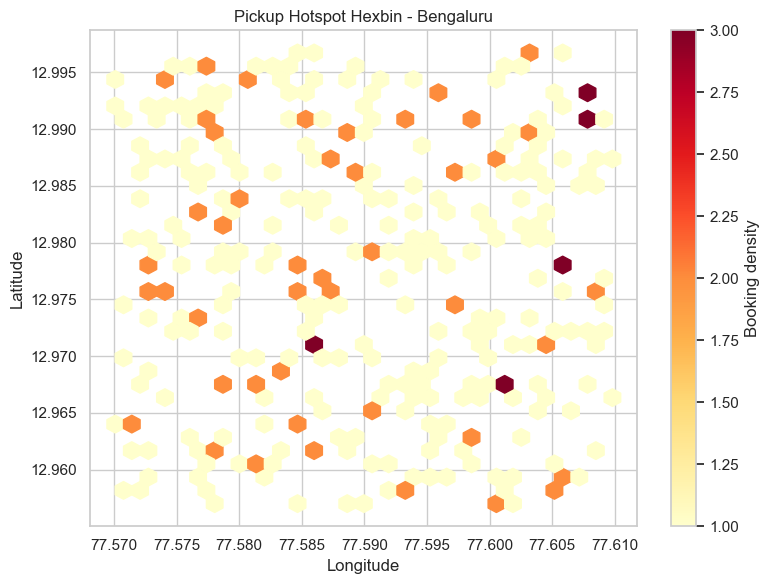

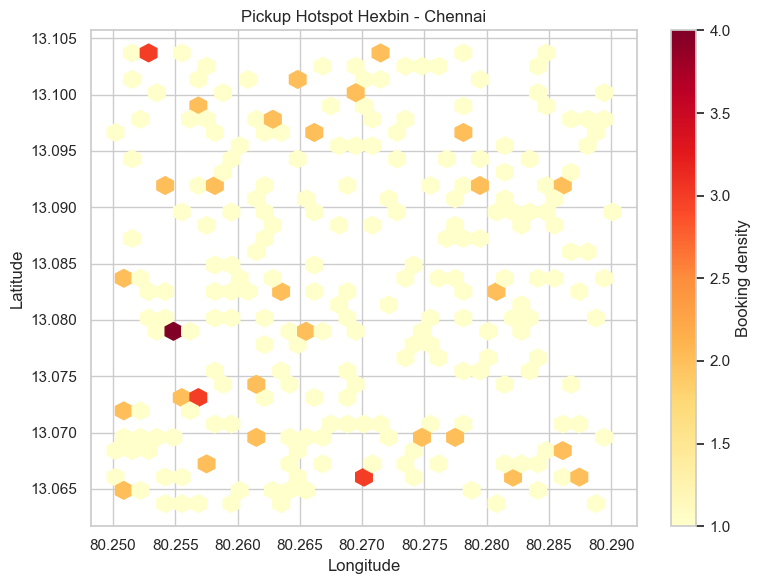

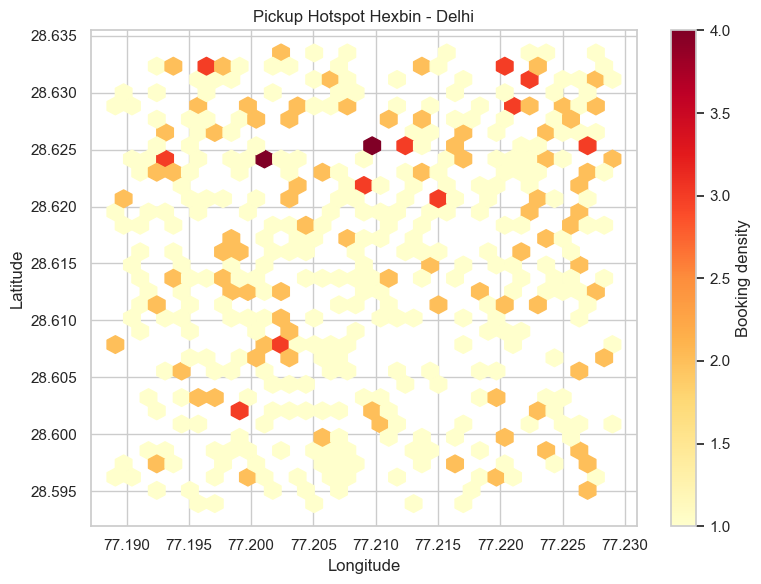

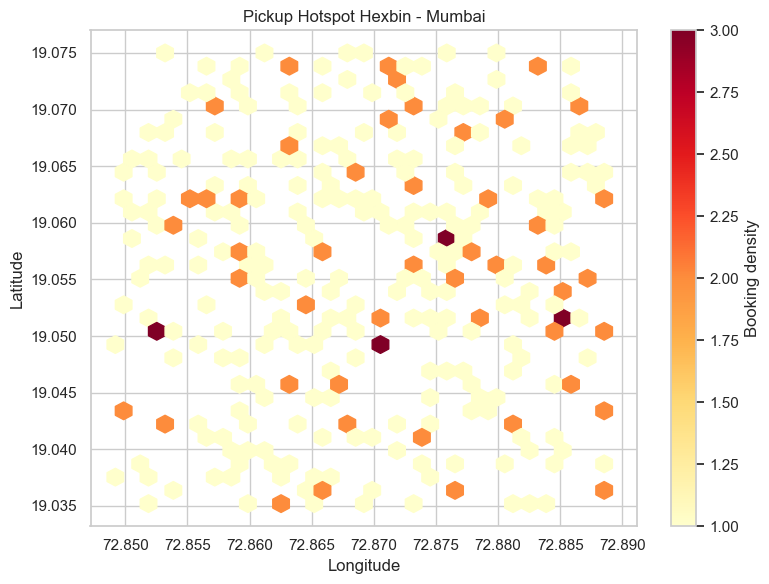

         City  lat_bin  lon_bin  bookings
67      Delhi    28.62    77.21        41
61      Delhi    28.61    77.20        41
68      Delhi    28.62    77.22        38
66      Delhi    28.62    77.20        38
73      Delhi    28.63    77.22        38
71      Delhi    28.63    77.20        35
88     Mumbai    19.06    72.88        31
57      Delhi    28.60    77.21        30
8   Bengaluru    12.97    77.60        29
56      Delhi    28.60    77.20        29
87     Mumbai    19.06    72.87        27
72      Delhi    28.63    77.21        27
62      Delhi    28.61    77.21        27
11  Bengaluru    12.98    77.58        26
63      Delhi    28.61    77.22        26


In [14]:
geo = df[df["is_completed"]].dropna(subset=["GPS_Lat", "GPS_Lon"]).copy()

# Heatmap per city
for city, data in geo.groupby("City"):

    plt.figure(figsize=(8, 6))
    plt.hexbin(data["GPS_Lon"], data["GPS_Lat"], gridsize=30, cmap="YlOrRd", mincnt=1)
    plt.colorbar(label="Booking density")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Pickup Hotspot Hexbin - {city}")

    plt.tight_layout()
    plt.show()


# Identify hotspot zones
hotspots = (
    geo.assign(
        lat_bin=geo["GPS_Lat"].round(2),
        lon_bin=geo["GPS_Lon"].round(2)
    )
    .groupby(["City", "lat_bin", "lon_bin"], dropna=False)
    .size()
    .reset_index(name="bookings")
    .sort_values("bookings", ascending=False)
)

print(hotspots.head(15))

## 14) Upsell/cross-sell opportunity flags (addons)


In [15]:
upsell = df.copy()
notes = upsell["Notes"].fillna("").str.lower()

upsell["addon_navigation"] = notes.str.contains("navigation")
upsell["addon_cleaning"] = notes.str.contains("clean")
upsell["addon_fuel_plan"] = notes.str.contains("fuel") | (upsell["Fuel_Level"].fillna(0.5) < 0.25)
upsell["addon_protection"] = upsell["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | upsell["Damage_Flag"].isin(["Minor", "Major"])

flag_cols = ["addon_navigation", "addon_cleaning", "addon_fuel_plan", "addon_protection"]
upsell["upsell_flag_count"] = upsell[flag_cols].sum(axis=1)
upsell["upsell_opportunity"] = upsell["upsell_flag_count"] > 0

upsell_summary = upsell.groupby("City", dropna=False).agg(
    rentals=("Reservation_ID", "count"),
    opportunities=("upsell_opportunity", "sum"),
).reset_index()
upsell_summary["opportunity_rate"] = 100 * upsell_summary["opportunities"] / upsell_summary["rentals"]

print(upsell_summary.sort_values("opportunity_rate", ascending=False))


        City  rentals  opportunities  opportunity_rate
3     Mumbai     1061            953             89.82
1    Chennai      798            714             89.47
2      Delhi     1627           1443             88.69
0  Bengaluru     1041            920             88.38


## 15) Cancellation rate and reasons analysis


         City Vehicle_Class  total_bookings  cancelled  cancellation_rate
30     Mumbai        Suzuki             129         53              41.09
12    Chennai           SUV              80         31              38.75
17      Delhi            EV             182         70              38.46
22      Delhi        Suzuki             200         76              38.00
5   Bengaluru         Sedan             136         51              37.50
7   Bengaluru        Toyota             117         43              36.75
24     Mumbai         Creta             187         67              35.83
2   Bengaluru     Hatchback             151         54              35.76
31     Mumbai        Toyota             145         51              35.17
19      Delhi        Luxury             189         65              34.39
28     Mumbai           SUV             112         38              33.93
6   Bengaluru        Suzuki             122         41              33.61

Cancellation reason distribution:
  c

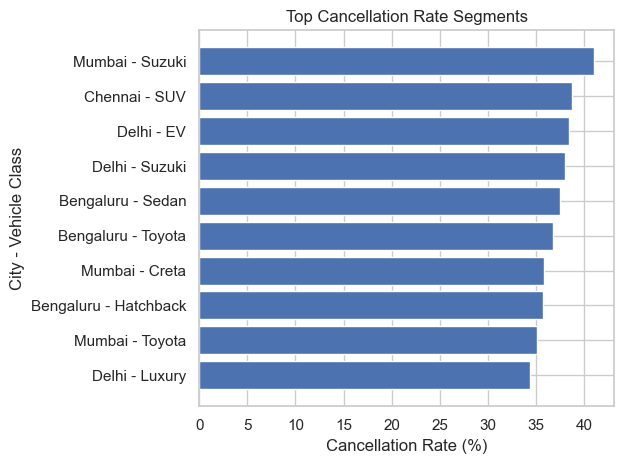

In [16]:
cancel = df.copy()

# Clean status
cancel["Booking_Status"] = cancel["Booking_Status"].str.strip().str.title()

# Correct flags
cancel["is_cancelled"] = cancel["Booking_Status"] == "Cancelled"
cancel["is_no_show"] = cancel["Booking_Status"] == "No_Show"


cancel_rate = cancel.groupby(["City", "Vehicle_Class"]).agg(
    total_bookings=("Reservation_ID", "count"),
    cancelled=("is_cancelled", "sum"),
).reset_index()

cancel_rate["cancellation_rate"] = 100 * cancel_rate["cancelled"] / cancel_rate["total_bookings"]

cancel_rate = cancel_rate[cancel_rate["total_bookings"] >= 50]

print(cancel_rate.sort_values("cancellation_rate", ascending=False).head(12))


notes = cancel["Notes"].fillna("").str.lower()

cancel["cancel_reason_bucket"] = np.select(
    [
        notes.str.contains("traffic"),
        notes.str.contains("fuel"),
        notes.str.contains("clean"),
        notes.str.contains("scratch|damage"),
        notes.str.contains("early pickup"),
        notes.str.contains("no notes"),
    ],
    ["Traffic", "Fuel", "Cleaning", "Damage Concern", "Schedule Change", "Unspecified"],
    default="Other",
)

reason_dist = cancel[cancel["is_cancelled"]].groupby("cancel_reason_bucket").size().reset_index(name="count")

print("\nCancellation reason distribution:")
print(reason_dist.sort_values("count", ascending=False))

import matplotlib.pyplot as plt

# Sort and take top 10 for clarity
plot_df = cancel_rate.sort_values("cancellation_rate", ascending=False).head(10)

# Create combined label
plot_df["label"] = plot_df["City"] + " - " + plot_df["Vehicle_Class"]

plt.figure()

plt.barh(plot_df["label"], plot_df["cancellation_rate"])

plt.xlabel("Cancellation Rate (%)")
plt.ylabel("City - Vehicle Class")
plt.title("Top Cancellation Rate Segments")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 16) Driver behavior scoring from telematics


     Customer_ID  trips  avg_driver_score
1256   CUST-1388      1             43.84
551    CUST-0596      1             45.39
1022   CUST-1126      1             46.20
1683   CUST-1858      1             47.13
811    CUST-0892      1             47.27
1580   CUST-1748      1             47.56
596    CUST-0644      1             48.20
346    CUST-0375      1             48.29
457    CUST-0497      2             49.54
1170   CUST-1289      2             49.93
1276   CUST-1410      1             52.02
1478   CUST-1636      1             52.34
1419   CUST-1572      1             52.37
476    CUST-0516      1             52.39
830    CUST-0913      1             52.91
744    CUST-0816      1             54.05
693    CUST-0761      1             54.23
717    CUST-0787      2             54.56
1552   CUST-1717      2             55.35
1698   CUST-1875      1             56.02


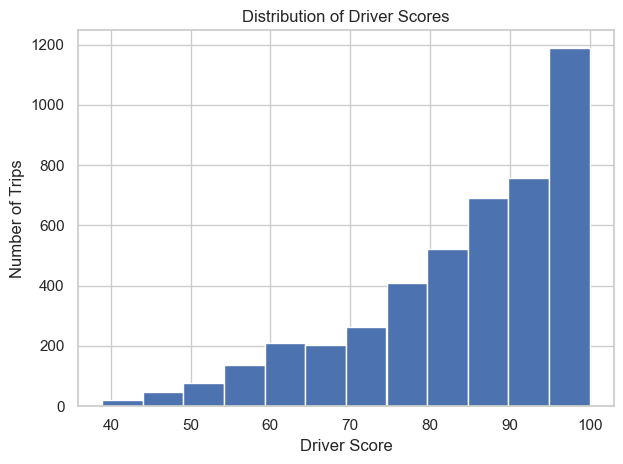

In [17]:
driver = df.copy()
driver["driver_score"] = 100

# Penalties
driver["driver_score"] -= np.where(driver["Speed"] > 120, 20,
                           np.where(driver["Speed"] > 100, 10, 0))

driver["driver_score"] -= np.where(driver["Driver_Behavior"].eq("Speeding"), 15,
                           np.where(driver["Driver_Behavior"].eq("Fast Driving"), 8, 0))

driver["driver_score"] -= np.where(driver["Damage_Flag"].eq("Major"), 15,
                           np.where(driver["Damage_Flag"].eq("Minor"), 5, 0))

np.random.seed(42)
driver["driver_score"] += np.random.normal(0, 5, size=len(driver))

# Keep range
driver["driver_score"] = driver["driver_score"].clip(0, 100)

# Aggregate
driver_summary = driver.groupby("Customer_ID").agg(
    trips=("Reservation_ID", "count"),
    avg_driver_score=("driver_score", "mean"),
).reset_index().sort_values("avg_driver_score")

print(driver_summary.head(20))

plt.figure()
plt.hist(driver["driver_score"], bins=12)

plt.xlabel("Driver Score")
plt.ylabel("Number of Trips")
plt.title("Distribution of Driver Scores")

plt.tight_layout()
plt.show()

## 17) Vehicle class mix optimization


         City Vehicle_Class  utilization    RevPAC  mix_score       mix_action
1   Bengaluru        Toyota         0.75  7,819.00       1.00   Increase share
7   Bengaluru        Luxury         0.44  5,757.00       0.42  Hold / optimize
18  Bengaluru           SUV         0.34  5,191.00       0.24     Reduce share
16  Bengaluru        Suzuki         0.35  4,608.00       0.19     Reduce share
22  Bengaluru     Hatchback         0.31  4,561.00       0.15     Reduce share
24  Bengaluru         Sedan         0.28  4,826.00       0.14     Reduce share
26  Bengaluru            EV         0.26  4,087.00       0.03     Reduce share
29  Bengaluru         Creta         0.23  4,104.00       0.00     Reduce share
4     Chennai        Suzuki         0.58  7,911.00       0.92   Increase share
2     Chennai         Sedan         0.65  6,278.00       0.85   Increase share
6     Chennai            EV         0.49  7,159.00       0.73   Increase share
9     Chennai        Toyota         0.42  6,316.00  

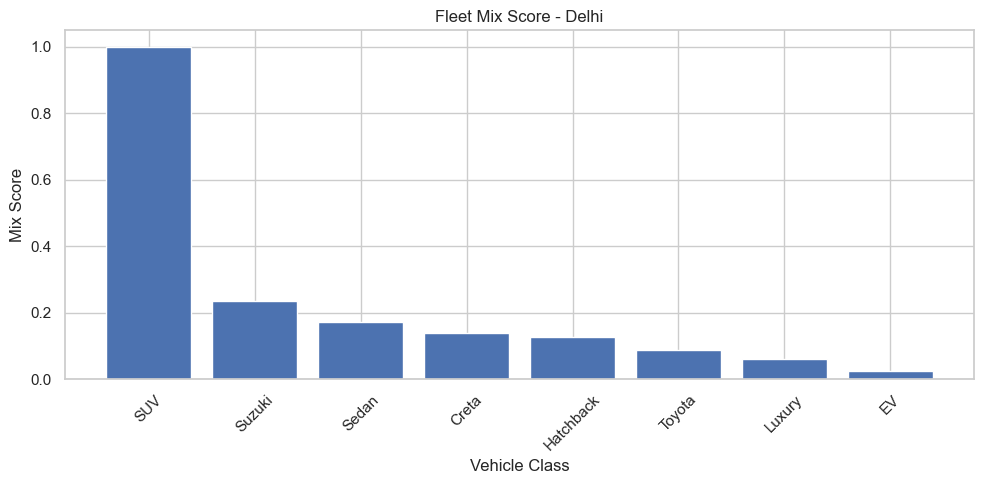

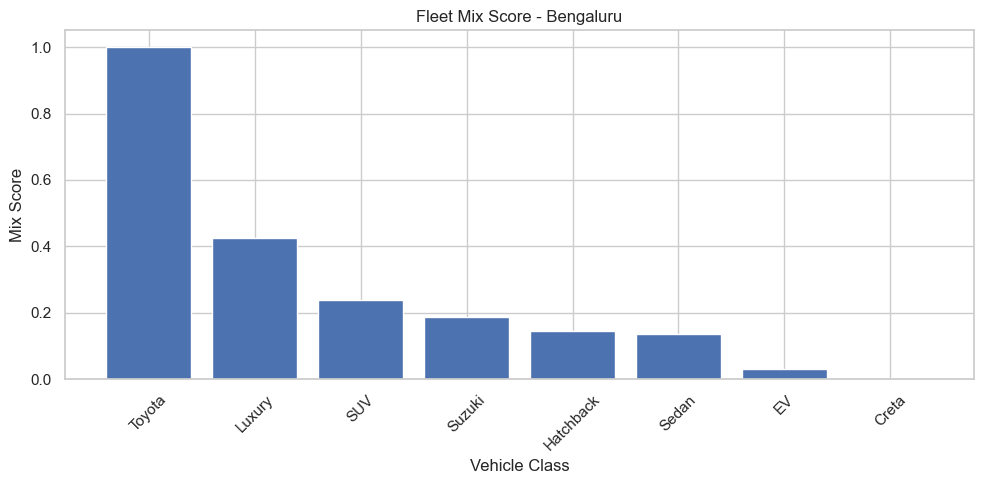

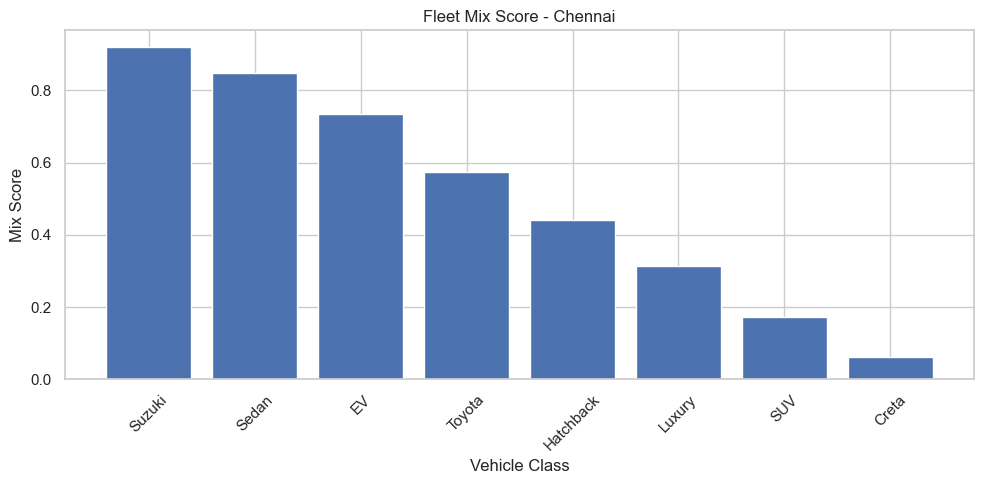

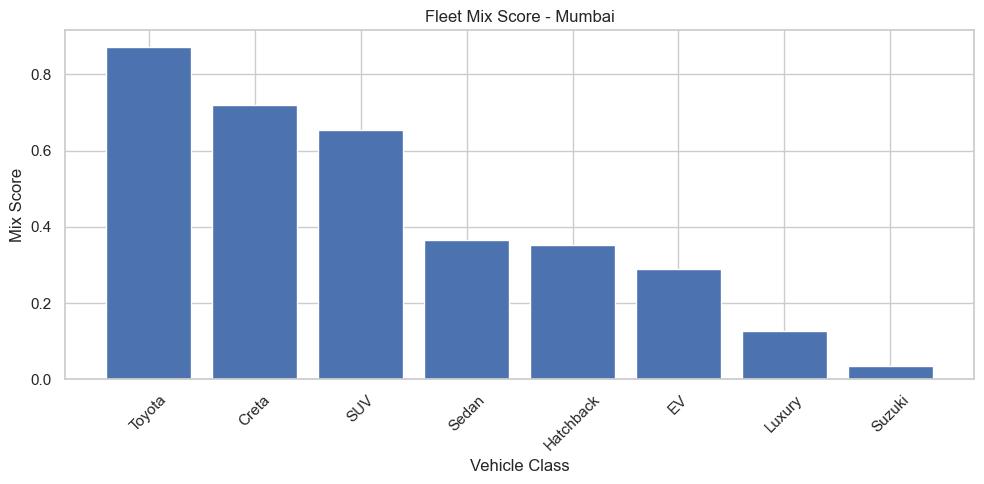

In [18]:
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

mix = util.merge(rev_metrics[["City", "Vehicle_Class", "RevPAC"]], on=["City", "Vehicle_Class"], how="left")
mix["fleet_share"] = mix.groupby("City")["available_cars"].transform(lambda s: s / max(s.sum(), 1))

mix["util_norm"] = mix.groupby("City")["utilization"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["rev_norm"] = mix.groupby("City")["RevPAC"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["mix_score"] = 0.6 * mix["util_norm"] + 0.4 * mix["rev_norm"]

mix["mix_action"] = np.where(mix["mix_score"] >= 0.66, "Increase share", np.where(mix["mix_score"] >= 0.33, "Hold / optimize", "Reduce share"))

final_mix = mix[
    ["City", "Vehicle_Class", "utilization", "RevPAC", "mix_score", "mix_action"]
].copy()

final_mix["utilization"] = final_mix["utilization"].round(2)
final_mix["RevPAC"] = final_mix["RevPAC"].round(0)
final_mix["mix_score"] = final_mix["mix_score"].round(2)

print(final_mix.sort_values(["City", "mix_score"], ascending=[True, False]))

import matplotlib.pyplot as plt

# Create a copy of clean data
plot_df = mix[["City", "Vehicle_Class", "mix_score", "mix_action"]].copy()

# Loop through each city
for city in plot_df["City"].unique():
    city_df = plot_df[plot_df["City"] == city].sort_values("mix_score", ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(city_df["Vehicle_Class"], city_df["mix_score"])

    plt.title(f"Fleet Mix Score - {city}")
    plt.xlabel("Vehicle Class")
    plt.ylabel("Mix Score")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 18) Lead-time price elasticity features


          City Vehicle_Class lead_time_bucket  price_elasticity
53     Chennai        Suzuki              NaN            -44.13
58       Delhi         Creta           Medium            -29.39
35     Chennai     Hatchback           Medium            -14.08
30     Chennai         Creta              NaN            -11.70
24   Bengaluru        Toyota           Medium            -10.52
14   Bengaluru           SUV           Medium             -9.51
76       Delhi         Sedan           Medium             -9.06
114     Mumbai        Toyota           Medium             -8.32
64       Delhi            EV              NaN             -6.60
87      Mumbai         Creta             Long             -5.81
67       Delhi     Hatchback              NaN             -5.71
88      Mumbai         Creta              NaN             -5.00
91      Mumbai            EV             Long             -4.94
6    Bengaluru            EV              NaN             -4.60
69       Delhi        Luxury           M

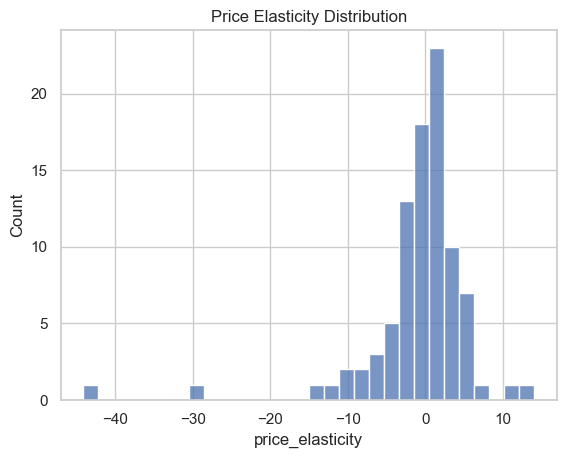

In [19]:
elastic = df.copy()

elastic["week"] = elastic["Booking_TS"].dt.to_period("W").astype(str)

weekly = elastic.groupby(["City", "Vehicle_Class", "week"], dropna=False).agg(
    bookings=("Reservation_ID", "count"),
    avg_rate=("Rate", "mean"),
    avg_lead_time=("lead_time_hours", "mean"),
).reset_index()

# NEW: Lead time segmentation
weekly["lead_time_bucket"] = pd.cut(
    weekly["avg_lead_time"],
    bins=[0, 6, 24, 72, 999],
    labels=["Last_Minute", "Short", "Medium", "Long"],
    include_lowest=True
)

def elasticity_proxy(g):
    g = g[(g["bookings"] > 0) & (g["avg_rate"] > 0)].dropna(subset=["bookings", "avg_rate"])

    if len(g) < 3 or g["avg_rate"].nunique() < 2:
        return np.nan

    x = np.log(g["avg_rate"])
    y = np.log(g["bookings"])

    return np.cov(x, y, bias=True)[0, 1] / (np.var(x) + 1e-9)


# UPDATED GROUPING
elasticity_table = (
    weekly.groupby(["City", "Vehicle_Class", "lead_time_bucket"], dropna=False)
    .apply(elasticity_proxy)
    .reset_index(name="price_elasticity")
)

print(elasticity_table.sort_values("price_elasticity").head(20))


# Visualization
sns.histplot(elasticity_table["price_elasticity"].dropna(), bins=30)
plt.title("Price Elasticity Distribution")
plt.show()

## 19) Fleet health score combining faults and usage


In [20]:
health_src = df.copy()
notes = health_src["Notes"].fillna("").str.lower()

health_src["fault_points"] = (
    np.where(health_src["Damage_Flag"].eq("Major"), 20, 0)
    + np.where(health_src["Damage_Flag"].eq("Minor"), 10, 0)
    + np.where(notes.str.contains("alert|malfunction|scratch"), 8, 0)
)

health_src["usage_hours_component"] = np.where(
    health_src["is_completed"],
    health_src["rental_hours"].fillna(0),
    0
)

health = health_src.groupby(["Vehicle_ID", "Vehicle_Class"], dropna=False).agg(
    fault_points=("fault_points", "sum"),
    usage_hours=("usage_hours_component", "sum"),
    avg_speed=("Speed", "mean"),
    rentals=("Reservation_ID", "count"),
).reset_index()

health["fault_norm"] = health["fault_points"] / (health["fault_points"].max() + 1e-9)
health["usage_norm"] = health["usage_hours"] / (health["usage_hours"].max() + 1e-9)

# UPDATED SPEED NORMALIZATION
max_speed = health["avg_speed"].max()
health["speed_norm"] = (health["avg_speed"].fillna(0) / max_speed).clip(0, 1)

health["fleet_health_score"] = 100 - (
    50 * health["fault_norm"] +
    30 * health["usage_norm"] +
    20 * health["speed_norm"]
)

health["fleet_health_score"] = health["fleet_health_score"].clip(0, 100)

health["health_band"] = pd.cut(
    health["fleet_health_score"],
    bins=[0, 50, 75, 100],
    labels=["Poor", "Moderate", "Healthy"],
    include_lowest=True
)

print(
    health[
        ["Vehicle_ID","Vehicle_Class","fleet_health_score","health_band"]
    ].head(20)
)

   Vehicle_ID Vehicle_Class  fleet_health_score health_band
0     CAR-001        Suzuki               69.81    Moderate
1     CAR-002        Toyota               64.36    Moderate
2     CAR-003     Hatchback               72.01    Moderate
3     CAR-005           SUV               48.21        Poor
4     CAR-006        Luxury               67.15    Moderate
5     CAR-007        Toyota               73.53    Moderate
6     CAR-008     Hatchback               65.27    Moderate
7     CAR-009         Creta               76.64     Healthy
8     CAR-010         Sedan               59.58    Moderate
9     CAR-011        Luxury               70.47    Moderate
10    CAR-012         Creta               54.87    Moderate
11    CAR-013            EV               77.88     Healthy
12    CAR-014     Hatchback               55.51    Moderate
13    CAR-015         Sedan               55.58    Moderate
14    CAR-016        Suzuki               75.67     Healthy
15    CAR-017        Luxury             

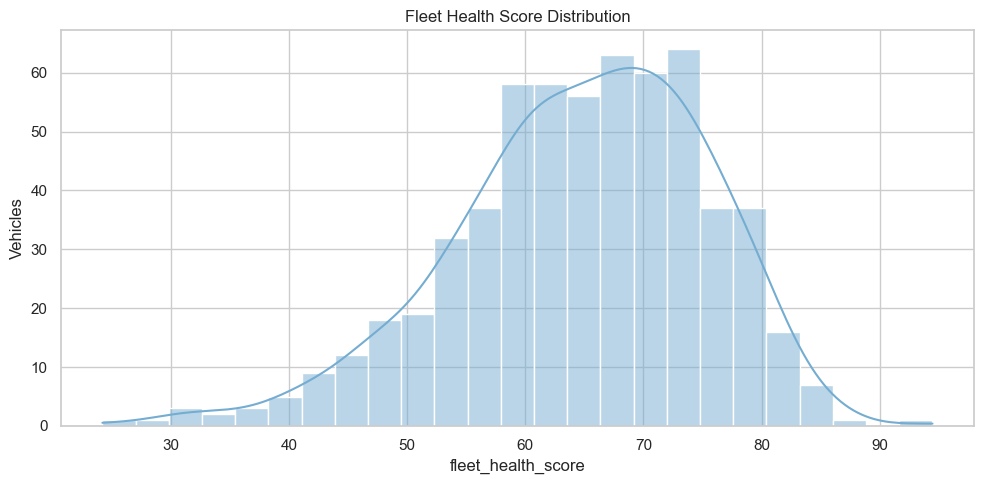

In [21]:
# Visualization: fleet health score distribution
health_plot = health.dropna(subset=["fleet_health_score"]).copy()

if health_plot.empty:
    print("No fleet health records available for plotting.")
else:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=health_plot, x="fleet_health_score", bins=25, kde=True, color="#74add1")
    plt.title("Fleet Health Score Distribution")
    plt.xlabel("fleet_health_score")
    plt.ylabel("Vehicles")
    plt.tight_layout()
    plt.show()

## 20) Churn likelihood for subscription rentals


Subscription proxy: customers with at least 3 bookings in the dataset are treated as subscription-like customers.


             total_bookings         last_booking  bookings_recent_90  bookings_prev_90  days_since_last_booking  drop_ratio  recency_norm  drop_norm  churn_likelihood churn_band
Customer_ID                                                                                                                                                                      
CUST-1190                 7  2025-05-13 00:00:00                0.00              1.00                      175        1.00          0.97       0.70              0.90       High
CUST-1472                 6  2025-05-14 00:00:00                0.00              1.00                      174        1.00          0.97       0.70              0.85       High
CUST-0653                 6  2025-05-17 00:00:00                0.00              1.00                      171        1.00          0.95       0.70              0.85       High
CUST-0356                 7  2025-06-06 00:00:00                0.00              2.00                      15

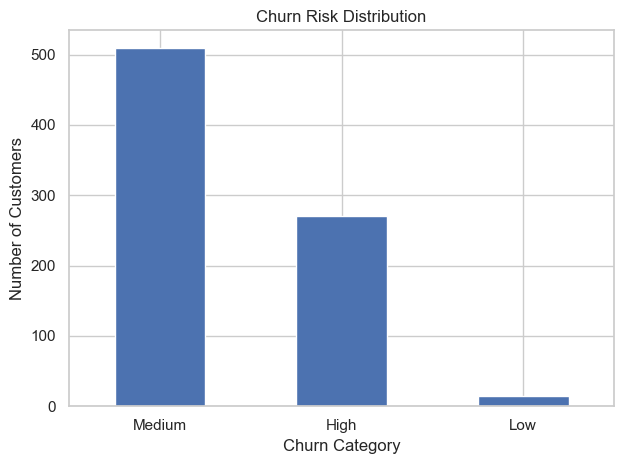

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

churn_src = df.copy()
churn_src["booking_date"] = churn_src["Booking_TS"].dt.floor("D")


cust_counts = churn_src.groupby("Customer_ID")["Reservation_ID"].count().rename("total_bookings")
subs = cust_counts[cust_counts >= 3].index
sub_df = churn_src[churn_src["Customer_ID"].isin(subs)].copy()

snapshot = sub_df["booking_date"].max() + pd.Timedelta(days=1) if not sub_df.empty else pd.Timestamp.today().normalize()

last_booking = sub_df.groupby("Customer_ID")["booking_date"].max().rename("last_booking")
sub_df["days_ago"] = (snapshot - sub_df["booking_date"]).dt.days

recent_90 = sub_df[sub_df["days_ago"] <= 90].groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_recent_90")

prev_90 = sub_df[(sub_df["days_ago"] > 90) & (sub_df["days_ago"] <= 180)] \
    .groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_prev_90")

churn = pd.concat([cust_counts, last_booking, recent_90, prev_90], axis=1).fillna(0)
churn = churn.loc[churn.index.isin(subs)].copy()


churn["days_since_last_booking"] = (snapshot - pd.to_datetime(churn["last_booking"])).dt.days

churn["drop_ratio"] = np.where(
    churn["bookings_prev_90"] > 0,
    (churn["bookings_prev_90"] - churn["bookings_recent_90"]) / churn["bookings_prev_90"],
    0
)


churn["recency_norm"] = (churn["days_since_last_booking"] / 180).clip(0, 1)
churn["drop_norm"] = (churn["drop_ratio"] * 0.7).clip(0, 1)


churn["churn_likelihood"] = (
    0.4 * churn["recency_norm"] +
    0.3 * churn["drop_norm"] +
    0.3 * (churn["total_bookings"] / churn["total_bookings"].max())
).clip(0, 1)


churn["churn_band"] = pd.cut(
    churn["churn_likelihood"],
    bins=[-0.01, 0.4, 0.7, 1.0],
    labels=["Low", "Medium", "High"]
)

print(churn.sort_values("churn_likelihood", ascending=False).head(20))

print("\nChurn Risk Distribution:")
print(churn["churn_band"].value_counts())


plt.figure()
churn["churn_band"].value_counts().plot(kind="bar")

plt.xlabel("Churn Category")
plt.ylabel("Number of Customers")
plt.title("Churn Risk Distribution")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()